# Agent-4: Non-Markovian Dynamics와 Quantum Combs

이 노트북은 Choi representation이 single quantum channel에서 작은 multi-time process tensor로 어떻게 확장되는지 보여 준다. Multi-time process는 quantum comb Choi operator `T`로 표현한다. 프로젝트 convention은 다음과 같다.

$$C_{\mathcal{E}} = \sum_{ij} |i\rangle\langle j| \otimes \mathcal{E}(|i\rangle\langle j|),$$

따라서 input system이 첫 번째 tensor factor이다. Quantum comb `T`에서는 subsystem order를 `A0, B0, A1, B1, ...`로 둔다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from choi_common.metrics import trace_distance
from choi_common.representations import (
    apply_choi_channel,
    choi_to_natural,
    natural_to_choi,
)
from combs_tools import (
    blp_measure,
    comb_global_trace_preservation_check,
    deterministic_comb_causality_check,
    is_markovian,
    marginal_channel,
    rhp_measure,
)
from non_markovian_dynamics import (
    choi_abs_matrix,
    collision_model_comb,
    comb_correlation_norm,
    markovian_dephasing_family,
    memoryless_product_comb,
    pure_dephasing_choi,
)

np.random.seed(42)
PALETTE = {
    "blue": "#2F6BFF",
    "red": "#D1495B",
    "green": "#2A9D8F",
    "gold": "#F2B134",
    "ink": "#222222",
}
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. 왜 Single Channel만으로는 부족할 수 있는가

Memoryless dynamics에서는 time 0에서 time 2로 가는 map이 time 1을 거치는 valid intermediate channel로 factorize된다. 하지만 environmental memory가 있으면 time 0에서 각 fixed time으로 가는 map은 모두 완전히 valid한 CPTP channel일 수 있는데도, inferred intermediate map은 complete positivity를 만족하지 않을 수 있다.

이 관점이 RHP witness의 CP-divisibility intuition이다.

In [2]:
def revival_dephasing_family(time: float) -> np.ndarray:
    """Positive coherence with a revival, avoiding singular zero crossings."""
    g = np.exp(-0.08 * time) * (0.58 + 0.42 * np.cos(3.0 * time))
    return pure_dephasing_choi(float(g))

t1, t2 = 0.65, 1.30
C_t1 = revival_dephasing_family(t1)
C_t2 = revival_dephasing_family(t2)

# A naive semigroup approximation would use E(t1) twice.
S_t1 = choi_to_natural(C_t1, 2, 2)
C_semigroup = natural_to_choi(S_t1 @ S_t1, 2, 2)
semigroup_error = np.linalg.norm(C_t2 - C_semigroup, ord="fro")
print(f"|| C(t2) - C(t1) composed with C(t1) ||_F = {semigroup_error:.4f}")

|| C(t2) - C(t1) composed with C(t1) ||_F = 0.1209


## 2. BLP와 RHP-Style Grid Witnesses

아래 BLP estimate는 finite grid의 antipodal pure-state pair를 탐색한 뒤 trace distance가 증가하는 positive revival들을 합산한다. 따라서 full state-pair optimization이 아니라 sampled approximation이다.

RHP-style quantity는 discrete CP-divisibility witness이다. `t_grid`의 인접한 두 time point마다 natural representation에서 pseudo-inverse를 사용해 intermediate map을 재구성하고, 그 intermediate Choi matrix의 negative eigenvalue들을 합산한다. 이 값은 continuous RHP integral로 읽으면 안 된다.

Exponential dephasing family는 CP-divisible이고, revival family는 그렇지 않다.

BLP grid estimate, exponential dephasing: 0.000000
BLP grid estimate, revival dephasing:     0.699240
RHP-style grid witness, exponential:      0.000000
RHP-style grid witness, revival:          0.896321


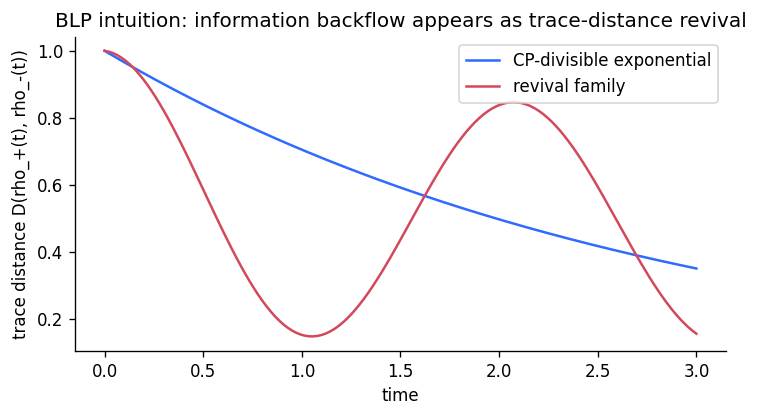

In [3]:
rho_plus = 0.5 * np.array([[1, 1], [1, 1]], dtype=complex)
rho_minus = 0.5 * np.array([[1, -1], [-1, 1]], dtype=complex)

t_grid = np.linspace(0.0, 3.0, 140)
markov_family = markovian_dephasing_family(rate=0.35)

def distance_curve(family):
    values = []
    for t in t_grid:
        C = family(float(t))
        values.append(trace_distance(apply_choi_channel(C, rho_plus), apply_choi_channel(C, rho_minus)))
    return np.array(values)

D_markov = distance_curve(markov_family)
D_revival = distance_curve(revival_dephasing_family)

blp_markov = blp_measure(markov_family, t_grid)
blp_revival = blp_measure(revival_dephasing_family, t_grid)
rhp_markov = rhp_measure(markov_family, t_grid)
rhp_revival = rhp_measure(revival_dephasing_family, t_grid)

print(f"BLP grid estimate, exponential dephasing: {blp_markov:.6f}")
print(f"BLP grid estimate, revival dephasing:     {blp_revival:.6f}")
print(f"RHP-style grid witness, exponential:      {rhp_markov:.6f}")
print(f"RHP-style grid witness, revival:          {rhp_revival:.6f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(t_grid, D_markov, color=PALETTE["blue"], label="CP-divisible exponential")
ax.plot(t_grid, D_revival, color=PALETTE["red"], label="revival family")
ax.set_xlabel("time")
ax.set_ylabel("trace distance D(rho_+(t), rho_-(t))")
ax.set_title("BLP intuition: information backflow appears as trace-distance revival")
ax.legend()
plt.show()

## 3. Generalized Choi Operator로서의 Quantum Comb

Two-use quantum comb `T`는 process tensor의 두 time slot 사이 correlation을 저장한다. Helper `construct_process_tensor`는 finite-memory collision model의 Choi operator를 만든다. 여기서는 system slot 0이 environment와 상호작용하고, 같은 environment가 다음 step으로 carry forward된 뒤, system slot 1이 다시 그 environment와 상호작용한다.

이 demonstration은 dense matrices와 explicit basis loops를 사용하므로 작은 qubit example을 위한 것이다. 만약 comb가 Markovian이라면, single-slot marginal Choi matrix들의 tensor product로 factorize되어야 한다.

comb shape: (16, 16)
positive minimum eigenvalue: -1.774e-16
global TP trace check: True
deterministic comb causality hierarchy: True
factorizes into product marginals: False
relative comb correlation norm: 0.5307


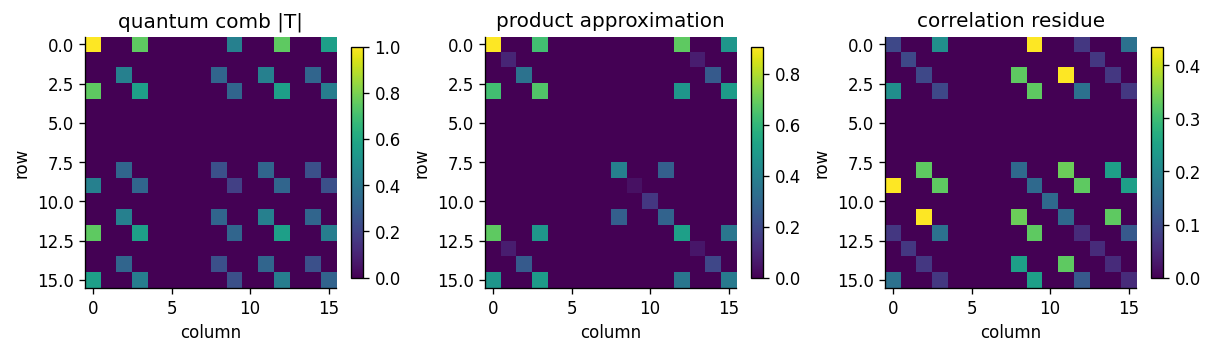

In [4]:
theta = 0.72
comb = collision_model_comb(theta=theta, n_steps=2)
product_comb = memoryless_product_comb(theta=theta, n_steps=2)

print(f"comb shape: {comb.shape}")
print(f"positive minimum eigenvalue: {np.linalg.eigvalsh(comb).min():.3e}")
print(f"global TP trace check: {comb_global_trace_preservation_check(comb, [2, 2, 2, 2])}")
print(f"deterministic comb causality hierarchy: {deterministic_comb_causality_check(comb, [2, 2, 2, 2])}")
print(f"factorizes into product marginals: {is_markovian(comb, n_steps=2, tol=1e-3)}")
print(f"relative comb correlation norm: {comb_correlation_norm(comb, n_steps=2):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), constrained_layout=True)
items = [
    (choi_abs_matrix(comb), "quantum comb |T|"),
    (choi_abs_matrix(product_comb), "product approximation"),
    (choi_abs_matrix(comb - product_comb), "correlation residue"),
]
for ax, (matrix, title) in zip(axes, items):
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 4. Marginal Channels와 Markovian Approximation

다른 time slot들을 partial trace하면 single-slot marginal Choi matrix를 얻을 수 있다. 이 marginal들은 유용하지만, temporal correlation 자체를 표현하지는 못한다.

위의 residue heatmap은 전체 comb를 marginal channel들의 product로 대체했을 때 사라지는 부분을 보여 준다. 이 residue가 바로 ordinary channel picture만으로는 놓치는 memory structure이다.

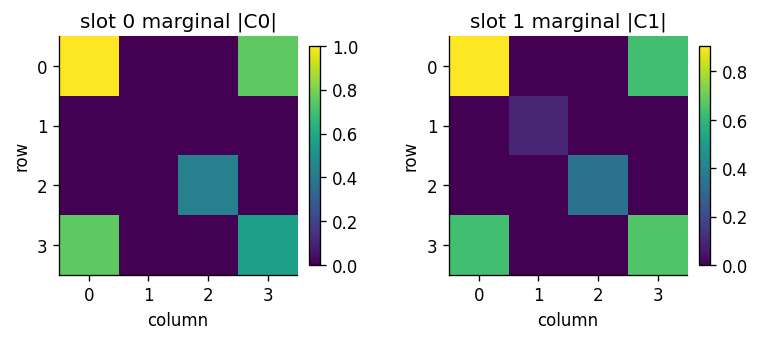

The marginals are valid single-time Choi matrices, but their product misses the memory residue.


In [5]:
C0 = marginal_channel(comb, 0)
C1 = marginal_channel(comb, 1)

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3), constrained_layout=True)
for ax, C, title in [(axes[0], C0, "slot 0 marginal |C0|"), (axes[1], C1, "slot 1 marginal |C1|")]:
    im = ax.imshow(choi_abs_matrix(C), cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("The marginals are valid single-time Choi matrices, but their product misses the memory residue.")

## 5. Takeaways

- Quantum comb `T`는 multi-time process tensor를 위한 Choi-like operator이다.
- BLP grid estimate는 sampled trace-distance revival, 즉 information backflow로 memory를 감지한다.
- RHP-style grid witness는 pseudo-inverse로 재구성한 intermediate map의 CP-divisibility failure로 memory를 감지한다.
- Explicit comb representation은 process를 ordinary channel들의 product로 바꿀 때 사라지는 correlation을 matrix 구조로 보여 준다.
- 비용은 빠르게 증가한다. Qubit `N`-step comb도 이미 matrix size가 `4**N` by `4**N`이 된다.